<a href="https://colab.research.google.com/github/raisaaajose/Raisa-EDA-Project/blob/main/Raisa_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# 1. Install and Load Libraries
if (!require("corrplot")) install.packages("corrplot")
library(tidyverse)
library(corrplot)

# 2. Loading the dataset
df <- read.csv("Auto.csv", stringsAsFactors = FALSE)

# 3. Handling Missing Data & Data Cleaning
# Check for NA values
print("Initial Missing values count per column:")
print(colSums(is.na(df)))

# Data Cleaning: Horsepower often has "?" in this dataset.
df$horsepower <- as.numeric(as.character(df$horsepower))

# Fill missing horsepower with the median value
df$horsepower[is.na(df$horsepower)] <- median(df$horsepower, na.rm = TRUE)

# Convert Origin and Cylinders to factors for better categorization and plotting
df$origin <- factor(df$origin, levels = c(1, 2, 3), labels = c("USA", "Europe", "Japan"))
df$cylinders <- as.factor(df$cylinders)

# 4. Data Transformation
# Create a new column: Weight per Horsepower
df <- df %>%
  mutate(weight_per_hp = weight / horsepower)

# Create a final clean dataframe
df_clean <- df %>% filter(!is.na(mpg))

# 5. Basic Statistical Analysis
print("Basic Statistical Summary")
print(summary(df_clean))






[1] "Initial Missing values count per column:"
         mpg    cylinders displacement   horsepower       weight acceleration 
           0            0            0            0            0            0 
        year       origin         name 
           0            0            0 
[1] "Basic Statistical Summary"
      mpg        cylinders  displacement     horsepower        weight    
 Min.   : 9.00   3:  4     Min.   : 68.0   Min.   : 46.0   Min.   :1613  
 1st Qu.:17.00   4:199     1st Qu.:105.0   1st Qu.: 75.0   1st Qu.:2225  
 Median :22.75   5:  3     Median :151.0   Median : 93.5   Median :2804  
 Mean   :23.45   6: 83     Mean   :194.4   Mean   :104.5   Mean   :2978  
 3rd Qu.:29.00   8:103     3rd Qu.:275.8   3rd Qu.:126.0   3rd Qu.:3615  
 Max.   :46.60             Max.   :455.0   Max.   :230.0   Max.   :5140  
  acceleration        year          origin           name     weight_per_hp  
 Min.   : 8.00   Min.   :70.00   USA   :245   Length   :392   Min.   :13.72  
 1st Qu.:

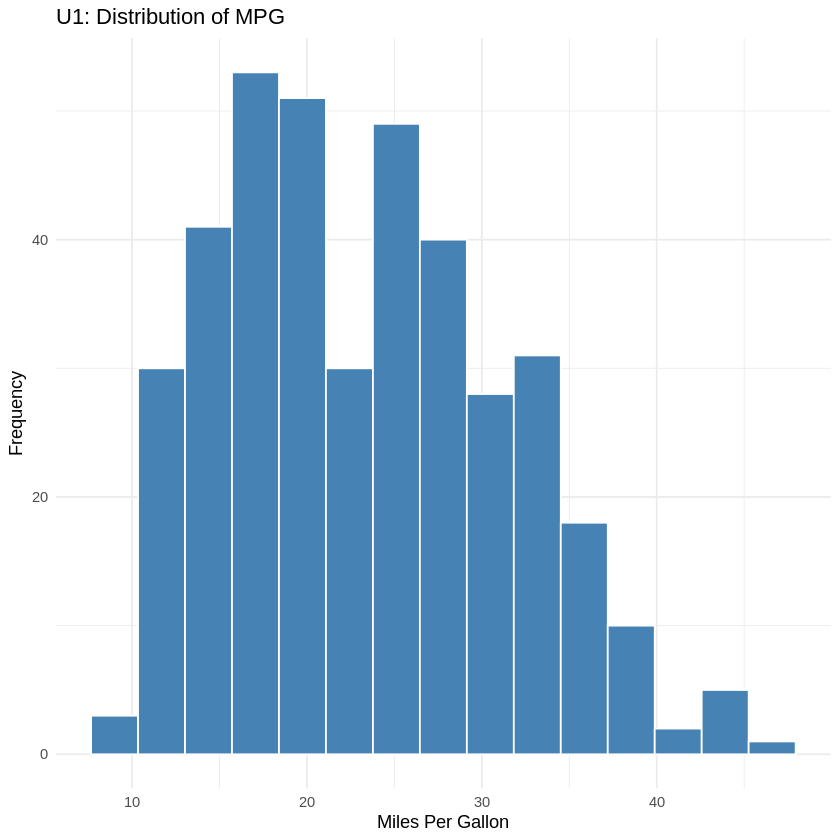

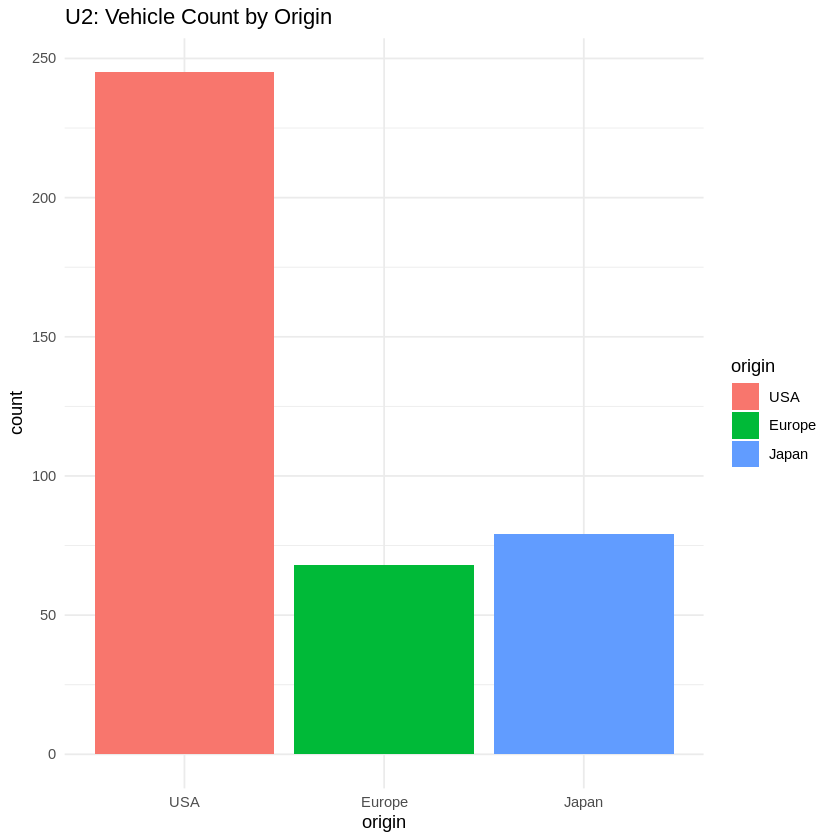

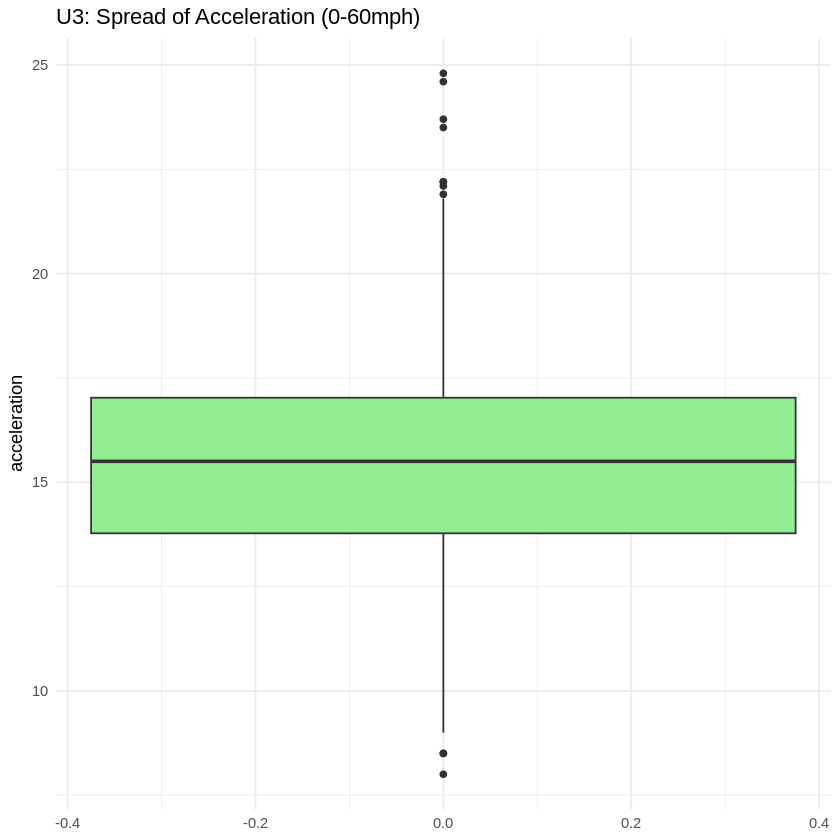

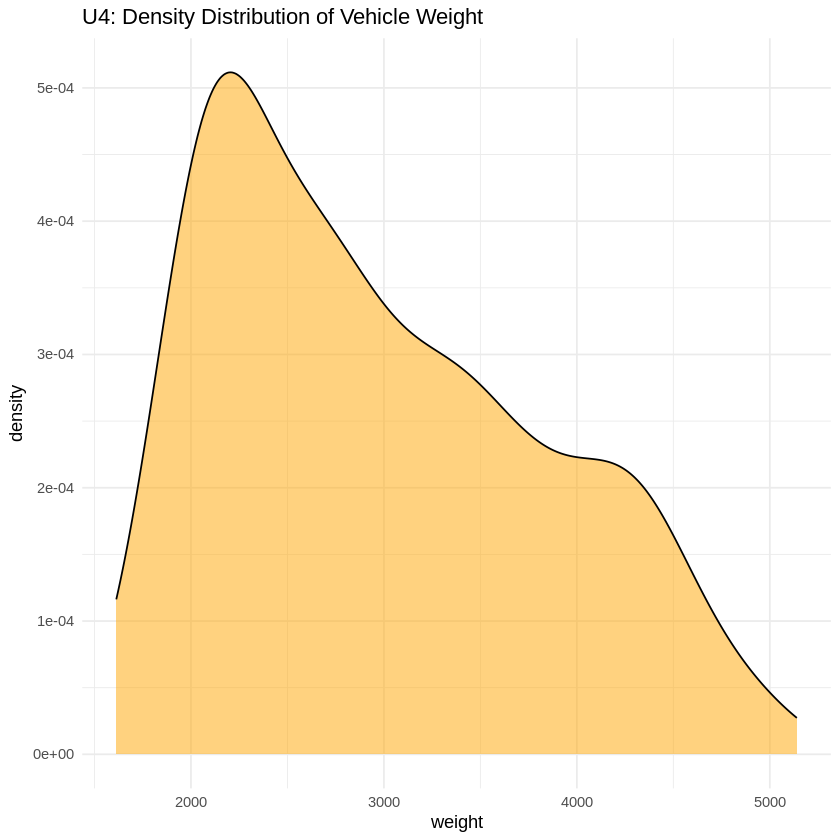

In [7]:
# 6. Univariate Analysis

# Viz 1: Histogram of MPG (Distribution)
p1 <- ggplot(df_clean, aes(x = mpg)) +
  geom_histogram(fill = "steelblue", color = "white", bins = 15) +
  theme_minimal() +
  labs(title = "U1: Distribution of MPG", x = "Miles Per Gallon", y = "Frequency")
print(p1)

# Viz 2: Count of Cars by Origin (Bar Chart)
p2 <- ggplot(df_clean, aes(x = origin, fill = origin)) +
  geom_bar() +
  theme_minimal() +
  labs(title = "U2: Vehicle Count by Origin")
print(p2)

# Viz 3: Spread of Acceleration (Boxplot)
p3 <- ggplot(df_clean, aes(y = acceleration)) +
  geom_boxplot(fill = "lightgreen") +
  theme_minimal() +
  labs(title = "U3: Spread of Acceleration (0-60mph)")
print(p3)

# Viz 4: Density of Vehicle Weight (Density Plot)
p4 <- ggplot(df_clean, aes(x = weight)) +
  geom_density(fill = "orange", alpha = 0.5) +
  theme_minimal() +
  labs(title = "U4: Density Distribution of Vehicle Weight")
print(p4)

`geom_smooth()` using formula = 'y ~ x'


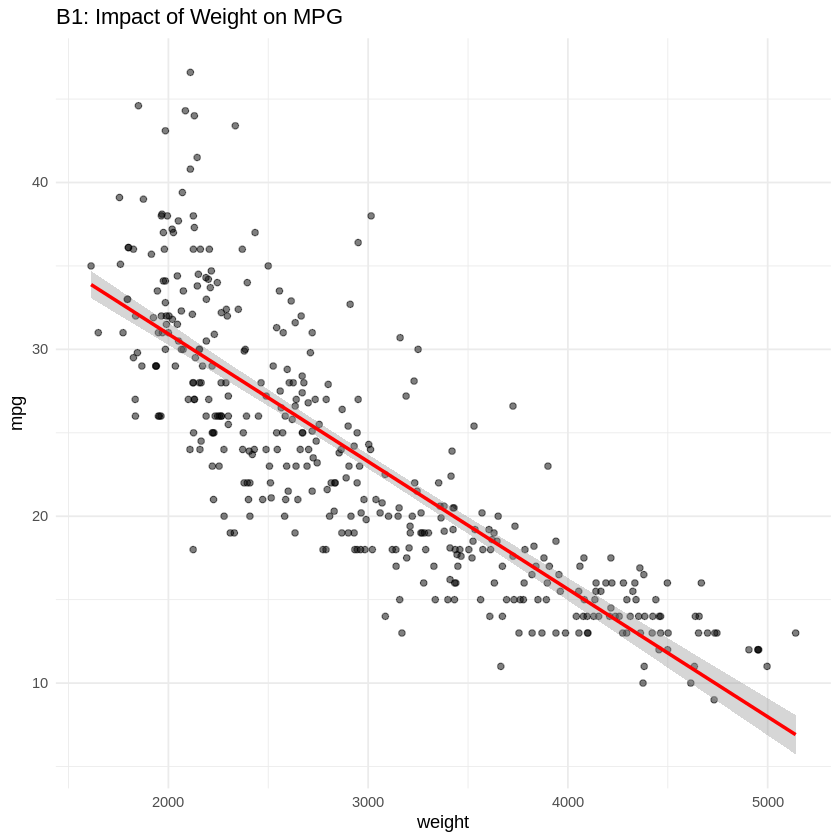

`geom_smooth()` using formula = 'y ~ x'


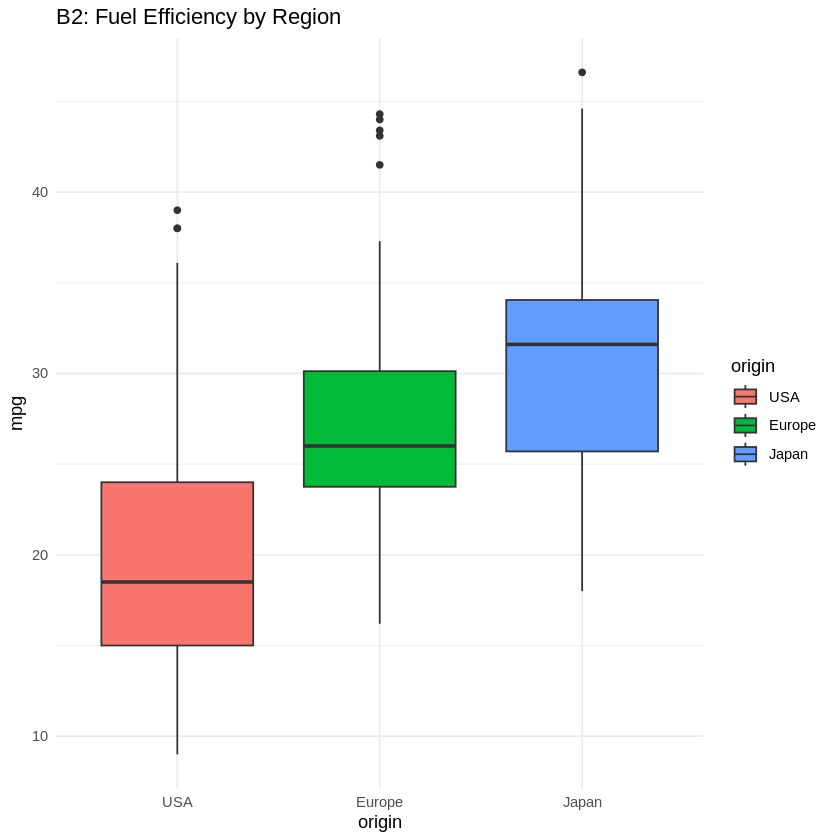

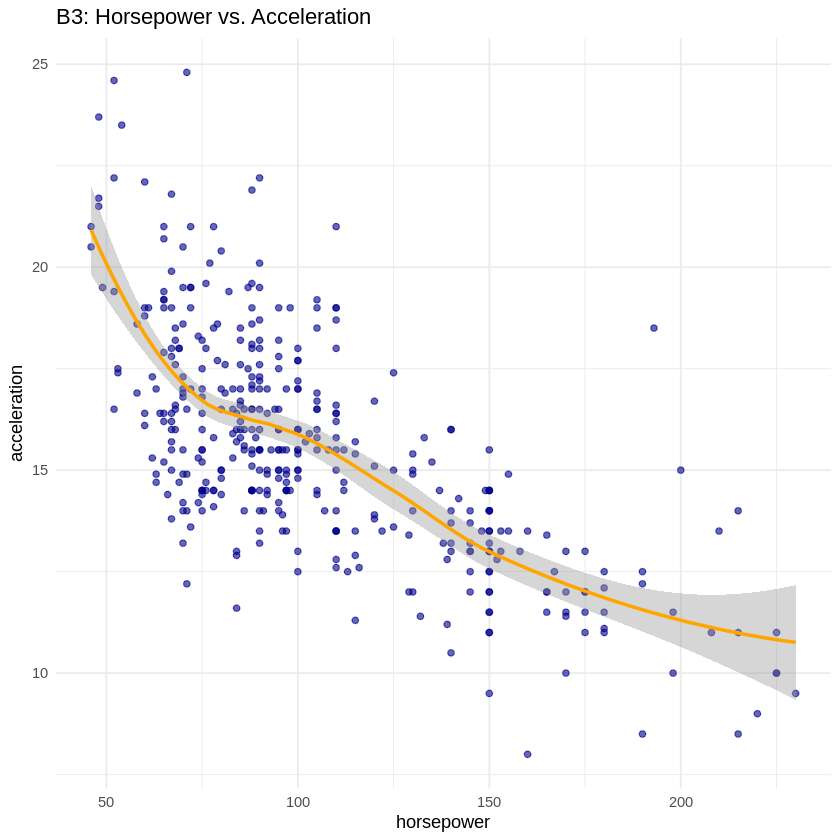

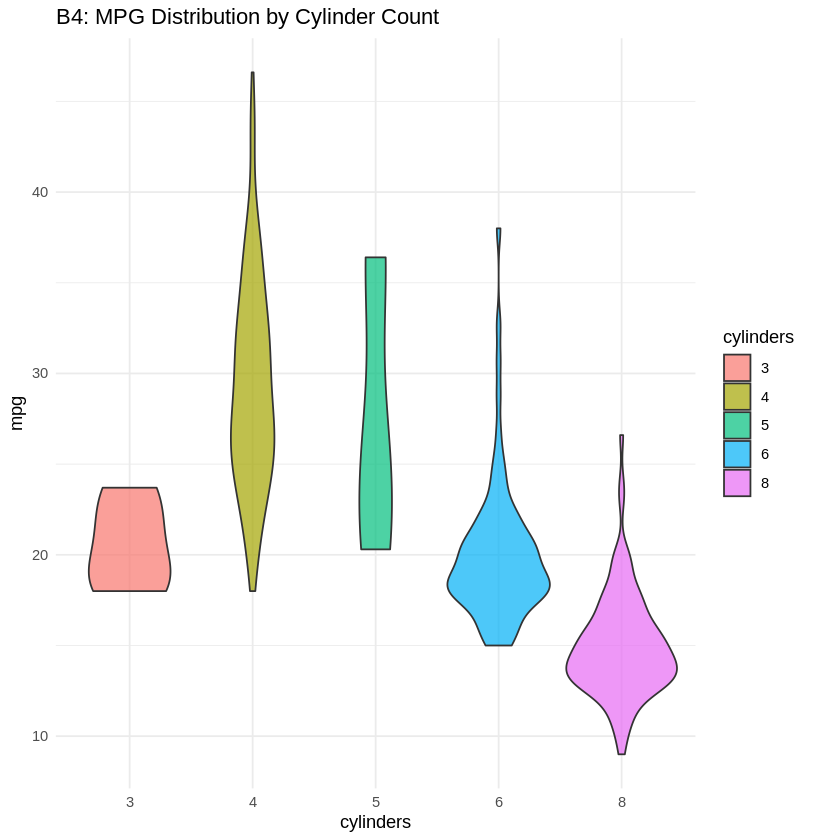

In [8]:
# 7. Bivariate Analysis

# Viz 1: MPG vs Weight (Scatter Plot + Regression Line)
p5 <- ggplot(df_clean, aes(x = weight, y = mpg)) +
  geom_point(alpha = 0.5) +
  geom_smooth(method = "lm", color = "red") +
  theme_minimal() +
  labs(title = "B1: Impact of Weight on MPG")
print(p5)

# Viz 2: MPG by Origin (Boxplot)
p6 <- ggplot(df_clean, aes(x = origin, y = mpg, fill = origin)) +
  geom_boxplot() +
  theme_minimal() +
  labs(title = "B2: Fuel Efficiency by Region")
print(p6)

# Viz 3: Horsepower vs Acceleration (Scatter Plot)
p7 <- ggplot(df_clean, aes(x = horsepower, y = acceleration)) +
  geom_point(color = "darkblue", alpha = 0.6) +
  geom_smooth(method = "loess", color = "orange") +
  theme_minimal() +
  labs(title = "B3: Horsepower vs. Acceleration")
print(p7)

# Viz 4: MPG by Cylinder Count (Violin Plot)
p8 <- ggplot(df_clean, aes(x = cylinders, y = mpg, fill = cylinders)) +
  geom_violin(alpha = 0.7) +
  theme_minimal() +
  labs(title = "B4: MPG Distribution by Cylinder Count")
print(p8)


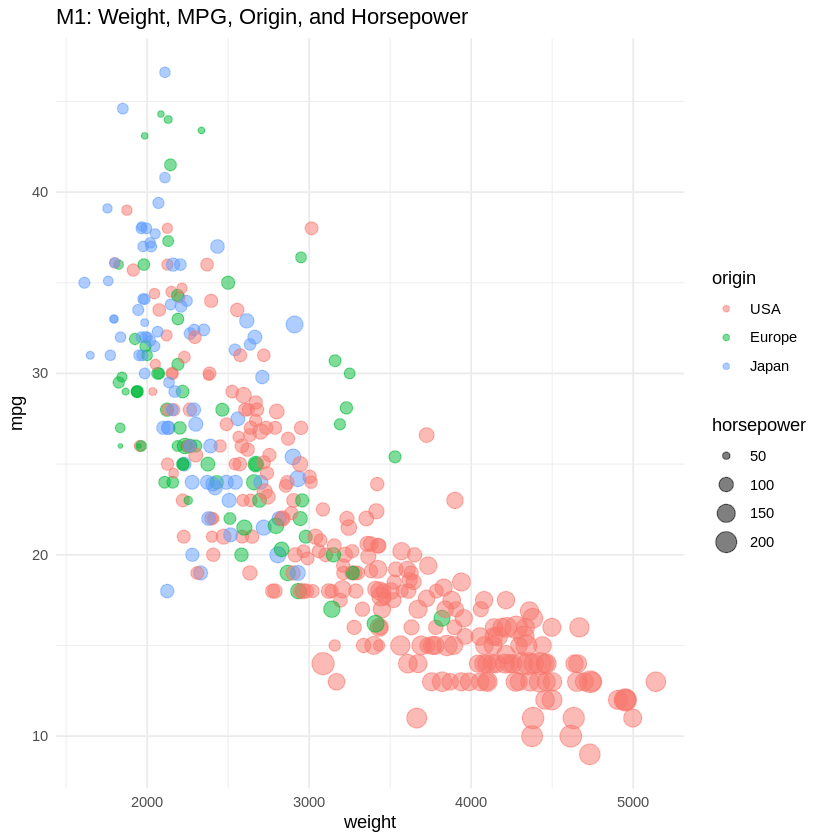

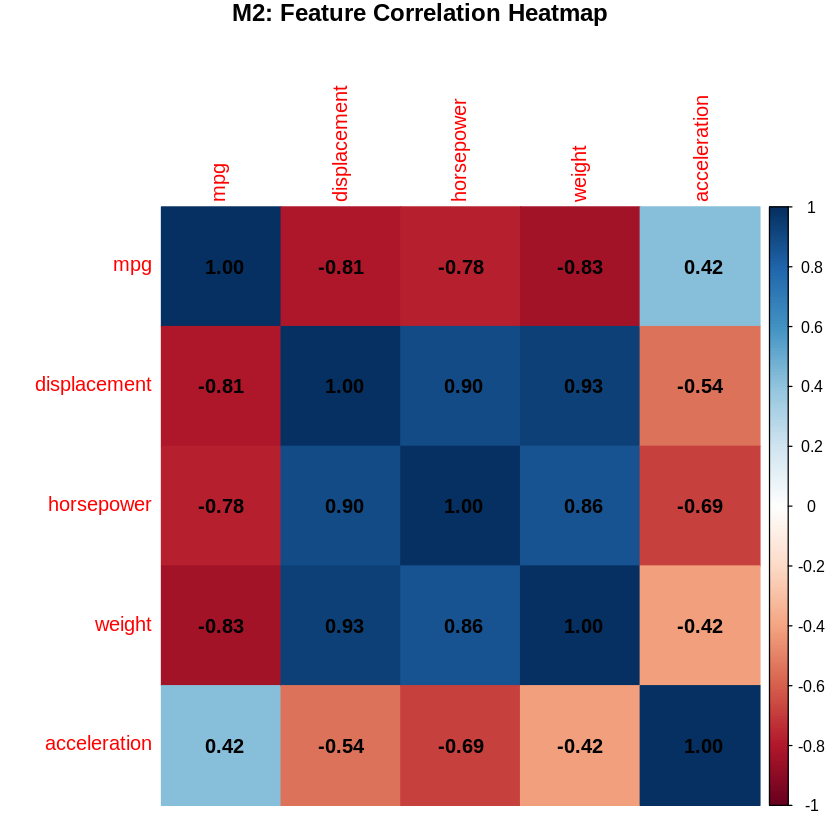

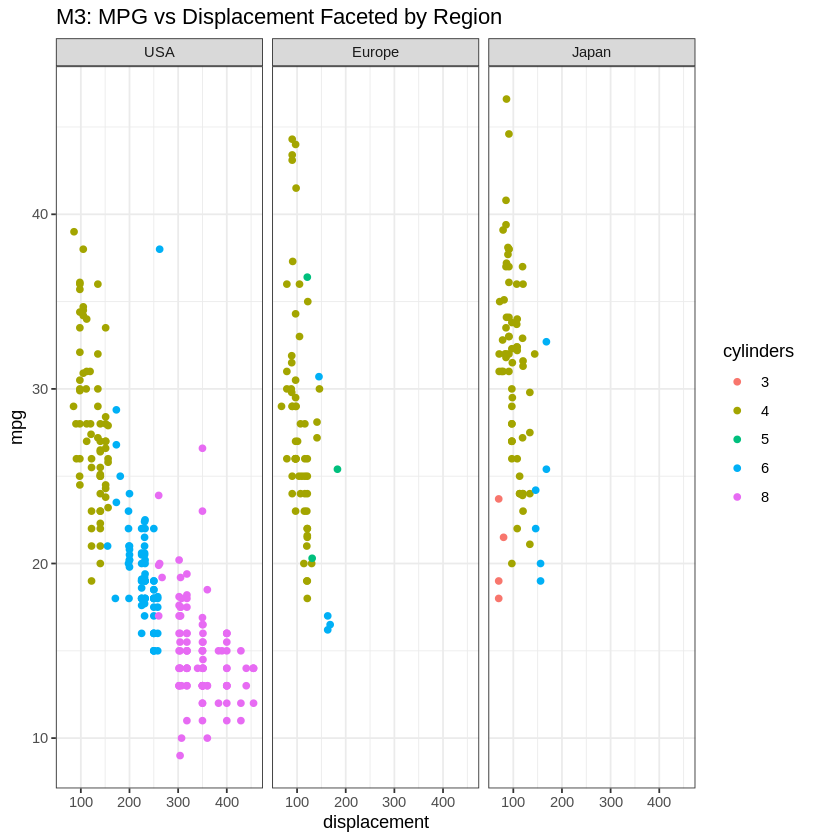

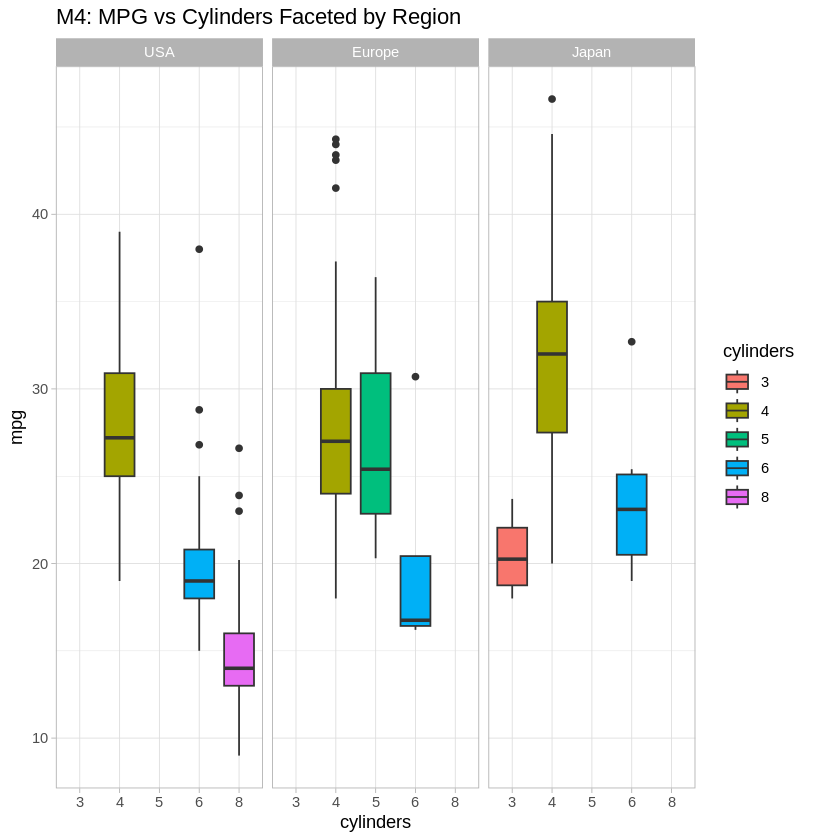

In [9]:
# 8. Multivariate Analysis

# Viz 1: Weight vs MPG colored by Origin and sized by HP
p9 <- ggplot(df_clean, aes(x = weight, y = mpg, color = origin, size = horsepower)) +
  geom_point(alpha = 0.5) +
  theme_minimal() +
  labs(title = "M1: Weight, MPG, Origin, and Horsepower")
print(p9)

# Viz 2: Correlation Heatmap (All numeric variables)
numeric_cols <- df_clean %>% select(mpg, displacement, horsepower, weight, acceleration)
cor_matrix <- cor(numeric_cols)
corrplot(cor_matrix, method = "color", addCoef.col = "black",
         title = "M2: Feature Correlation Heatmap", mar=c(0,0,1,0))

# Viz 3: Faceted Scatter Plot (MPG vs Displacement faceted by Origin)
p11 <- ggplot(df_clean, aes(x = displacement, y = mpg, color = cylinders)) +
  geom_point() +
  facet_wrap(~origin) +
  theme_bw() +
  labs(title = "M3: MPG vs Displacement Faceted by Region")
print(p11)

# Viz 4: Faceted Boxplot (MPG vs Cylinders faceted by Origin)
p12 <- ggplot(df_clean, aes(x = cylinders, y = mpg, fill = cylinders)) +
  geom_boxplot() +
  facet_wrap(~origin) +
  theme_light() +
  labs(title = "M4: MPG vs Cylinders Faceted by Region")
print(p12)